# Классификация kNN

Бабошин Никита Андреевич (6401-010302D)

## Считать в `pandas.DataFrame` любой источник данных: CSV, JSON, Excel-файл, HTML-таблицу и т.п.

   > Возможно, потребуется использовать два датасета: один для бинарной классификации, второй для многоклассовой.
   > Использование встроенных в `sklearn` датасетов или их аналогов с Kaggle не допускается.

Ссылки на источники:
1. https://www.kaggle.com/datasets/ankitverma2010/ecommerce-customer-churn-analysis-and-prediction
2. https://www.kaggle.com/datasets/kukuroo3/body-performance-data

In [1]:
import kagglehub
import os

path1 = kagglehub.dataset_download("ankitverma2010/ecommerce-customer-churn-analysis-and-prediction")
path2 = kagglehub.dataset_download("kukuroo3/body-performance-data")

print(os.listdir(path1))
print(os.listdir(path2))

['E Commerce Dataset.xlsx']
['bodyPerformance.csv']


In [2]:
import pandas as pd
import os

full_file_path1 = os.path.join(path1, 'E Commerce Dataset.xlsx')
df1 = pd.read_excel(full_file_path1, sheet_name='E Comm', usecols='A:T')
df1.head()

,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,159.93
1,50002,1,NaN,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,120.90
2,50003,1,NaN,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120.28
3,50004,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134.07
4,50005,1,0.0,Phone,1,12.0,CC,Male,NaN,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,129.60


In [3]:
full_file_path2 = os.path.join(path2, 'bodyPerformance.csv')
df2 = pd.read_csv(full_file_path2)
df2.head()

,age,gender,height_cm,weight_kg,body fat_%,diastolic,systolic,gripForce,sit and bend forward_cm,sit-ups counts,broad jump_cm,class
0,27.0,M,172.3,75.24,21.3,80.0,130.0,54.9,18.4,60.0,217.0,C
1,25.0,M,165.0,55.80,15.7,77.0,126.0,36.4,16.3,53.0,229.0,A
2,31.0,M,179.6,78.00,20.1,92.0,152.0,44.8,12.0,49.0,181.0,C
3,32.0,M,174.5,71.10,18.4,76.0,147.0,41.4,15.2,53.0,219.0,B
4,28.0,M,173.8,67.70,17.1,70.0,127.0,43.5,27.1,45.0,217.0,B


## Бинарная классификация

### Привести описние датасета

Датасет "Ecommerce Customer Churn Analysis and Prediction" содержит данные, собранные ведущей онлайн-компанией электронной коммерции для анализа и прогнозирования оттока клиентов (churn). В нём представлены различные признаки клиентов, включая уникальный идентификатор, флаг оттока, срок сотрудничества с компанией и т.п. Цель датасета — выявить клиентов, которые, вероятно, прекратят пользоваться услугами, чтобы компания могла предложить им специальные промо-акции и удержать.

Целевой признак: `Churn`

In [4]:
dictData = pd.read_excel(full_file_path1, sheet_name='Data Dict', usecols='C:D', skiprows=1)
dictData

,Variable,Discerption
0,CustomerID,Unique customer ID
1,Churn,Churn Flag
2,Tenure,Tenure of customer in organization
3,PreferredLoginDevice,Preferred login device of customer
4,CityTier,City tier
5,WarehouseToHome,Distance in between warehouse to home of customer
6,PreferredPaymentMode,Preferred payment method of customer
7,Gender,Gender of customer
8,HourSpendOnApp,Number of hours spend on mobile application or...
9,NumberOfDeviceRegistered,Total number of deceives is registered on part...


In [5]:
df1.info()

<class 'pandas.DataFrame'>
RangeIndex: 5630 entries, 0 to 5629
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   CustomerID                   5630 non-null   int64  
 1   Churn                        5630 non-null   int64  
 2   Tenure                       5366 non-null   float64
 3   PreferredLoginDevice         5630 non-null   str    
 4   CityTier                     5630 non-null   int64  
 5   WarehouseToHome              5379 non-null   float64
 6   PreferredPaymentMode         5630 non-null   str    
 7   Gender                       5630 non-null   str    
 8   HourSpendOnApp               5375 non-null   float64
 9   NumberOfDeviceRegistered     5630 non-null   int64  
 10  PreferedOrderCat             5630 non-null   str    
 11  SatisfactionScore            5630 non-null   int64  
 12  MaritalStatus                5630 non-null   str    
 13  NumberOfAddress              

### Осуществить предобработку данных (избавиться от `null`, убрать некоторые признаки и т.п.) &ndash; "подчистить данные".

#### Целевой признак

Проверка целевой переменной (пропусков):

In [6]:
df1['Churn'].isnull().sum()

np.int64(0)

Распределение целевой переменной

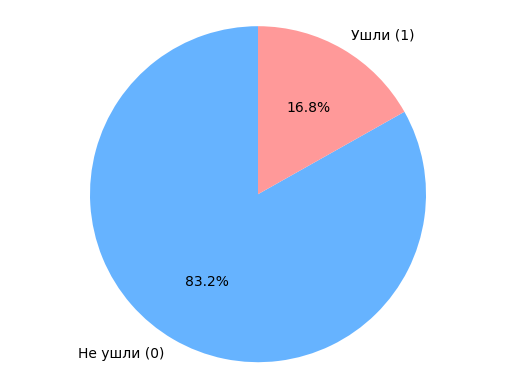

In [7]:
import matplotlib.pyplot as plt

counts = df1['Churn'].value_counts()

counts.plot.pie(
    labels=['Не ушли (0)', 'Ушли (1)'],
    autopct='%1.1f%%',
    startangle=90, 
    colors=['#66b3ff','#ff9999'],
    ylabel=''
)

plt.axis('equal')
plt.show()

Наблюдается сильный дисбаланс классов

#### Удаление признака CustomerID (не несет никакой информации)

In [8]:
df1 = df1.drop(['CustomerID'], axis=1)
df1.info()

<class 'pandas.DataFrame'>
RangeIndex: 5630 entries, 0 to 5629
Data columns (total 19 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Churn                        5630 non-null   int64  
 1   Tenure                       5366 non-null   float64
 2   PreferredLoginDevice         5630 non-null   str    
 3   CityTier                     5630 non-null   int64  
 4   WarehouseToHome              5379 non-null   float64
 5   PreferredPaymentMode         5630 non-null   str    
 6   Gender                       5630 non-null   str    
 7   HourSpendOnApp               5375 non-null   float64
 8   NumberOfDeviceRegistered     5630 non-null   int64  
 9   PreferedOrderCat             5630 non-null   str    
 10  SatisfactionScore            5630 non-null   int64  
 11  MaritalStatus                5630 non-null   str    
 12  NumberOfAddress              5630 non-null   int64  
 13  Complain                     

#### Катигориальные и числовые признаки

In [9]:
cat_columns = df1.select_dtypes(include="str").columns.tolist()

num_columns = []
for col in df1.columns:
    if col not in cat_columns:
        num_columns.append(col)

print("Numerical columns: ", num_columns)
print("Categorical columns: ", cat_columns)

Numerical columns:  ['Churn', 'Tenure', 'CityTier', 'WarehouseToHome', 'HourSpendOnApp', 'NumberOfDeviceRegistered', 'SatisfactionScore', 'NumberOfAddress', 'Complain', 'OrderAmountHikeFromlastYear', 'CouponUsed', 'OrderCount', 'DaySinceLastOrder', 'CashbackAmount']
Categorical columns:  ['PreferredLoginDevice', 'PreferredPaymentMode', 'Gender', 'PreferedOrderCat', 'MaritalStatus']


Значения категориальных признаков

In [10]:
for col in cat_columns:
    df1.fillna({col: df1[col].mode()[0]}, inplace=True)
    print(col, df1[col].unique())

PreferredLoginDevice <StringArray>
['Mobile Phone', 'Phone', 'Computer']
Length: 3, dtype: str
PreferredPaymentMode <StringArray>
['Debit Card', 'UPI', 'CC', 'Cash on Delivery', 'E wallet', 'COD',
 'Credit Card']
Length: 7, dtype: str
Gender <StringArray>
['Female', 'Male']
Length: 2, dtype: str
PreferedOrderCat <StringArray>
['Laptop & Accessory', 'Mobile', 'Mobile Phone', 'Others', 'Fashion',
 'Grocery']
Length: 6, dtype: str
MaritalStatus <StringArray>
['Single', 'Divorced', 'Married']
Length: 3, dtype: str


Пропуски в категориальных признаках

In [11]:
df1[cat_columns].isnull().sum()

PreferredLoginDevice    0
PreferredPaymentMode    0
Gender                  0
PreferedOrderCat        0
MaritalStatus           0
dtype: int64

Совместим похожие по смыслу значения в категориальных признаках

In [12]:
# Заменяем 'Mobile Phone' на 'Phone' в PreferredLoginDevice
df1['PreferredLoginDevice'] = df1['PreferredLoginDevice'].replace('Mobile Phone', 'Phone')

# Заменяем 'Credit Card' на 'CC' в PreferredPaymentMode
df1['PreferredPaymentMode'] = df1['PreferredPaymentMode'].replace('Credit Card', 'CC')

# Заменяем 'Mobile Phone' на 'Mobile' в PreferedOrderCat
df1['PreferedOrderCat'] = df1['PreferedOrderCat'].replace('Mobile Phone', 'Mobile')

Заполнение пропусков средним значением

In [13]:
df1[num_columns].isnull().sum()

Churn                            0
Tenure                         264
CityTier                         0
WarehouseToHome                251
HourSpendOnApp                 255
NumberOfDeviceRegistered         0
SatisfactionScore                0
NumberOfAddress                  0
Complain                         0
OrderAmountHikeFromlastYear    265
CouponUsed                     256
OrderCount                     258
DaySinceLastOrder              307
CashbackAmount                   0
dtype: int64

In [14]:
for col in num_columns:
    df1[col] = df1[col].fillna(df1[col].mean())

df1.info()

<class 'pandas.DataFrame'>
RangeIndex: 5630 entries, 0 to 5629
Data columns (total 19 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Churn                        5630 non-null   int64  
 1   Tenure                       5630 non-null   float64
 2   PreferredLoginDevice         5630 non-null   str    
 3   CityTier                     5630 non-null   int64  
 4   WarehouseToHome              5630 non-null   float64
 5   PreferredPaymentMode         5630 non-null   str    
 6   Gender                       5630 non-null   str    
 7   HourSpendOnApp               5630 non-null   float64
 8   NumberOfDeviceRegistered     5630 non-null   int64  
 9   PreferedOrderCat             5630 non-null   str    
 10  SatisfactionScore            5630 non-null   int64  
 11  MaritalStatus                5630 non-null   str    
 12  NumberOfAddress              5630 non-null   int64  
 13  Complain                     

### Закодировать категориальные признаки при необходимости.

One-Hot Encoding для категориальных признаков

In [15]:
df1 = pd.get_dummies(df1, columns=cat_columns, drop_first=True)
df1.info()

<class 'pandas.DataFrame'>
RangeIndex: 5630 entries, 0 to 5629
Data columns (total 27 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Churn                                  5630 non-null   int64  
 1   Tenure                                 5630 non-null   float64
 2   CityTier                               5630 non-null   int64  
 3   WarehouseToHome                        5630 non-null   float64
 4   HourSpendOnApp                         5630 non-null   float64
 5   NumberOfDeviceRegistered               5630 non-null   int64  
 6   SatisfactionScore                      5630 non-null   int64  
 7   NumberOfAddress                        5630 non-null   int64  
 8   Complain                               5630 non-null   int64  
 9   OrderAmountHikeFromlastYear            5630 non-null   float64
 10  CouponUsed                             5630 non-null   float64
 11  OrderCount     

### Выбрать какое-нибудь значение гиперпараметра $k$ алгоритма $kNN$.

In [16]:
from sklearn.neighbors import KNeighborsClassifier

k = 3
knn = KNeighborsClassifier(n_neighbors=k)

### Разбить выборку на обучающую и тестовую.
> Разбиение использовать одно и то же для всех последующих манипуляций.

In [17]:
from sklearn.model_selection import train_test_split

X = df1.drop(columns=["Churn"])
y = df1["Churn"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### При наличии дисбаланса классов снизить дисбаланс классов

In [18]:
from imblearn.over_sampling import ADASYN

adasyn = ADASYN(random_state=42)
X_train, y_train = adasyn.fit_resample(X_train, y_train)

### Осуществить бинарную классификацию.

In [19]:
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)

### Посчитать метрики: $accuracy$, $precision$, $recall$, $\textit{f-measure}$, а также составить `classification_report`.

In [20]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

acc_base = accuracy_score(y_test, y_pred)
prec_base = precision_score(y_test, y_pred)
rec_base = recall_score(y_test, y_pred)
f1_base = f1_score(y_test, y_pred)

print(f"Accuracy: {acc_base:.4f}")
print(f"Precision: {prec_base:.4f}")
print(f"Recall: {rec_base:.4f}")
print(f"F1-score: {f1_base:.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.8472
Precision: 0.5206
Recall: 0.8865
F1-score: 0.6560

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.84      0.90       941
           1       0.52      0.89      0.66       185

    accuracy                           0.85      1126
   macro avg       0.75      0.86      0.78      1126
weighted avg       0.90      0.85      0.86      1126



### Нормализовать данные (`StandardScaler`или `MinMaxScaler`).

In [21]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

### Осуществить бинарную классификацию.

In [22]:
knn_sc = KNeighborsClassifier(n_neighbors=k)
knn_sc.fit(X_train_sc, y_train)
y_pred_sc = knn_sc.predict(X_test_sc)

### Посчитать метрики: $accuracy$, $precision$, $recall$, $\textit{f-measure}$, а также составить `classification_report`.

In [23]:
acc_sc = accuracy_score(y_test, y_pred_sc)
prec_sc = precision_score(y_test, y_pred_sc)
rec_sc = recall_score(y_test, y_pred_sc)
f1_sc = f1_score(y_test, y_pred_sc)

print(f"Accuracy: {acc_sc:.4f}")
print(f"Precision: {prec_sc:.4f}")
print(f"Recall: {rec_sc:.4f}")
print(f"F1-score: {f1_sc:.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred_sc))

Accuracy: 0.9440
Precision: 0.7798
Recall: 0.9189
F1-score: 0.8437

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.95      0.97       941
           1       0.78      0.92      0.84       185

    accuracy                           0.94      1126
   macro avg       0.88      0.93      0.90      1126
weighted avg       0.95      0.94      0.95      1126



### Сравнить метрики на данных без нормализации и с применением нормализации.
> Далее используем нормализованные данные.

In [24]:
metrics_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-score'],
    'Base': [acc_base, prec_base, rec_base, f1_base],
    'Scaled': [acc_sc, prec_sc, rec_sc, f1_sc],
    'Delta': [
        acc_sc - acc_base,
        prec_sc - prec_base,
        rec_sc - rec_base,
        f1_sc - f1_base
    ]
}).round(4)

metrics_df

,Metric,Base,Scaled,Delta
0,Accuracy,0.8472,0.9440,0.0968
1,Precision,0.5206,0.7798,0.2592
2,Recall,0.8865,0.9189,0.0324
3,F1-score,0.6560,0.8437,0.1877


Модель после нормализации однозначно лучше: все метрики продемонстрировали рост. 

Улучшение обусловлено природой алгоритма kNN: нормализация выравнивает вклад всех признаков в расчёт расстояния, предотвращая доминирование признаков с большим разбросом значений и позволяя модели корректно определять границы классов.

### Построить `сorrelation heatmap` и/или воспользоваться методом `corr()`. Выбрать наиболее важные признаки эвристически или на основании каких-нибудь вычислений.

#### Сorrelation heatmap

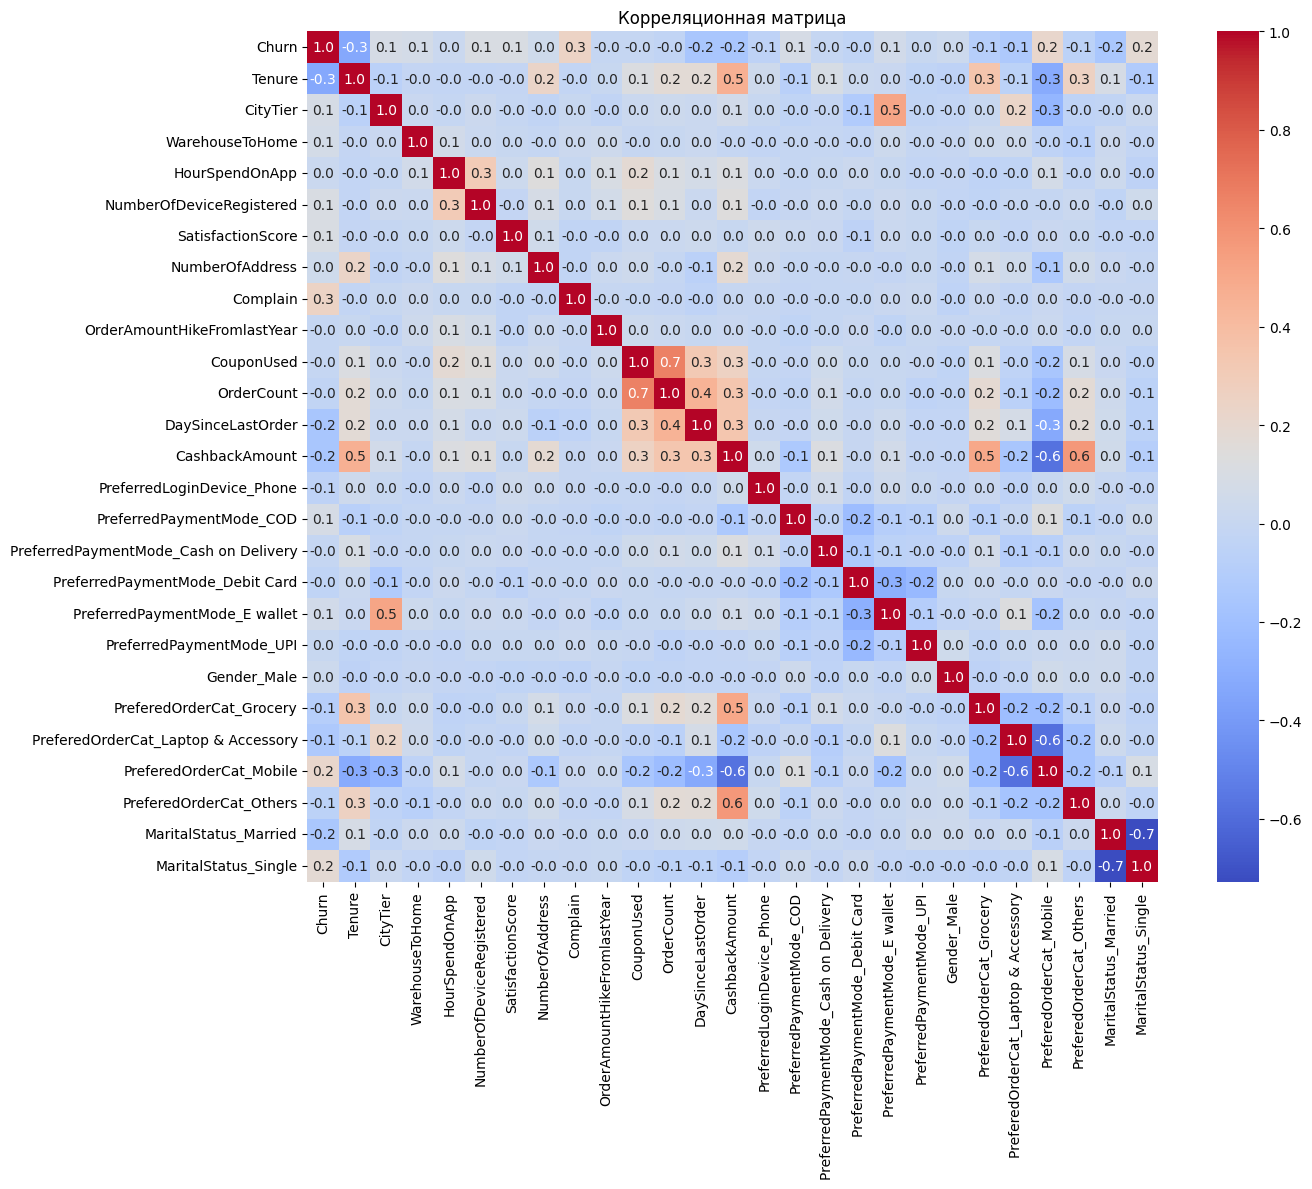

In [25]:
import seaborn as sns

correlation_matrix = df1.corr()

plt.figure(figsize=(15, 12))
sns.heatmap(correlation_matrix, 
            annot=True, 
            fmt='.1f', 
            cmap='coolwarm', 
            square=True)
plt.title('Корреляционная матрица')
plt.tight_layout()
plt.show()

#### Фильтрация признаков

In [26]:
from sklearn.feature_selection import SequentialFeatureSelector

knn_s = KNeighborsClassifier(n_neighbors=5)
sfs = SequentialFeatureSelector(knn_s, direction='backward', n_features_to_select='auto', cv=5)

sfs.fit(X_train_sc, y_train)
X_train_filtered = sfs.transform(X_train_sc)
X_test_filtered = sfs.transform(X_test_sc)

print(f"Осталось признаков: {sfs.n_features_to_select_}")

Осталось признаков: 13


### Осуществить бинарную классификацию с отфильтрованными признаками.

In [27]:
knn_f = KNeighborsClassifier(n_neighbors=k)
knn_f.fit(X_train_filtered, y_train)
y_pred_f = knn_f.predict(X_test_filtered)

### Посчитать метрики: $accuracy$, $precision$, $recall$, $\textit{f-measure}$, а также составить `classification_report`.

In [28]:
acc_f = accuracy_score(y_test, y_pred_f)
prec_f = precision_score(y_test, y_pred_f)
rec_f = recall_score(y_test, y_pred_f)
f1_f = f1_score(y_test, y_pred_f)

print(f"Accuracy: {acc_f:.4f}")
print(f"Precision: {prec_f:.4f}")
print(f"Recall: {rec_f:.4f}")
print(f"F1-score: {f1_f:.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred_f))

Accuracy: 0.9565
Precision: 0.8009
Recall: 0.9784
F1-score: 0.8808

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.95      0.97       941
           1       0.80      0.98      0.88       185

    accuracy                           0.96      1126
   macro avg       0.90      0.97      0.93      1126
weighted avg       0.96      0.96      0.96      1126



### Сравнить результаты "до" и "после" фильтрации, сделать выводы.
 > Естественно, искомые результаты &ndash; улучшение метрик.

In [29]:
metrics_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-score'],
    'Scaled': [acc_sc, prec_sc, rec_sc, f1_sc],
    'Filtered': [acc_f, prec_f, rec_f, f1_f],
    'Delta': [
        acc_f - acc_sc,
        prec_f - prec_sc,
        rec_f - rec_sc,
        f1_f - f1_sc
    ]
}).round(4)

metrics_df

,Metric,Scaled,Filtered,Delta
0,Accuracy,0.9440,0.9565,0.0124
1,Precision,0.7798,0.8009,0.0211
2,Recall,0.9189,0.9784,0.0595
3,F1-score,0.8437,0.8808,0.0371


Модель **после фильтрации признаков** демонстрирует лучшие результаты: все метрики улучшились, при этом наиболее значительный рост показал **Recall** (+0.0595), что критически важно для задач с дисбалансом классов, так как означает снижение количества пропущенных целевых событий (оттока клиентов). Улучшение **F1-score** (+0.0371) подтверждает, что модель стала не только полнее детектировать положительный класс, но и точнее в своих предсказаниях (Precision +0.0211). Это указывает на то, что `SequentialFeatureSelector` корректно отобрал подмножество признаков, которые действительно улучшают разделимость классов в пространстве расстояний kNN, исключив шумные или избыточные переменные, искажавшие метрику близости.

### Перебрать значения гиперпараметра $k$ в каком-нибудь диапазоне с использованием кросс-валидации на данных
> данных &ndash; исходных данных до разбиения с применением нормализации с отфильтрованными признаками. Построить график *train/test accuracy* в зависимости от значения $k$.

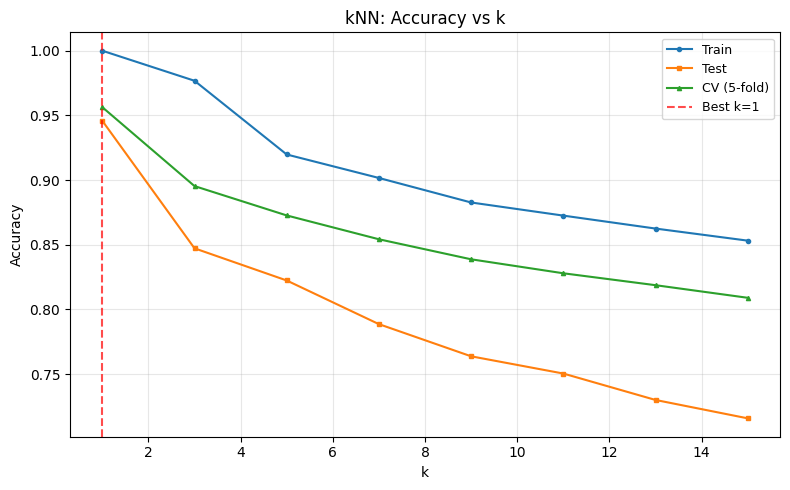

In [30]:
from sklearn.model_selection import cross_val_score
import numpy as np

k_range = range(1, 16, 2)
train_acc, test_acc, cv_acc = [], [], []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    train_acc.append(knn.score(X_train, y_train))
    test_acc.append(knn.score(X_test, y_test))
    cv_acc.append(cross_val_score(knn, X_train, y_train, cv=5).mean())

plt.figure(figsize=(8, 5))
plt.plot(k_range, train_acc, label='Train', marker='o', markersize=3)
plt.plot(k_range, test_acc, label='Test', marker='s', markersize=3)
plt.plot(k_range, cv_acc, label='CV (5-fold)', marker='^', markersize=3)

best_k = k_range[np.argmax(cv_acc)]
plt.axvline(best_k, color='red', linestyle='--', alpha=0.7, label=f'Best k={best_k}')

plt.xlabel('k')
plt.ylabel('Accuracy')
plt.title('kNN: Accuracy vs k')
plt.legend(fontsize=9)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Многоклассовая классификация

### Привести описание датасета

**Датасет Body Performance Data** содержит данные о физической подготовке и антропометрических показателях людей в возрасте 20–64 лет. Цель (целевой признак, таргет) — **многоклассовая классификация уровня физической подготовки** (`class`: A, B, C, D, где A — наилучший результат).

| Признак | Описание | Единицы измерения |
|---------|----------|------------------|
| `age` | Возраст участника | лет |
| `gender` | Пол участника | F (female), M (male) |
| `height_cm` | Рост | сантиметры (см) |
| `weight_kg` | Масса тела | килограммы (кг) |
| `body fat_%` | Процент жировой ткани в организме | % |
| `diastolic` | Диастолическое артериальное давление (нижнее, измерено утром) | мм рт. ст. |
| `systolic` | Систолическое артериальное давление (верхнее, измерено утром) | мм рт. ст. |
| `gripForce` | Сила сжатия кисти (динамометрия, лучшее из двух измерений) | кгс (килограмм-сила) |
| `sit and bend forward_cm` | Гибкость: наклон вперёд из положения сидя | сантиметры (см) |
| `sit-ups counts` | Количество подъёмов корпуса за фиксированное время (тест на выносливость пресса) | шт. |
| `broad jump_cm` | Длина прыжка в длину с места | сантиметры (см) |
| `class` | **Целевая переменная**: интегральная оценка физической подготовки | A (best), B, C, D (worst) |

Целевой признак: `class`

In [31]:
df2.head()

,age,gender,height_cm,weight_kg,body fat_%,diastolic,systolic,gripForce,sit and bend forward_cm,sit-ups counts,broad jump_cm,class
0,27.0,M,172.3,75.24,21.3,80.0,130.0,54.9,18.4,60.0,217.0,C
1,25.0,M,165.0,55.80,15.7,77.0,126.0,36.4,16.3,53.0,229.0,A
2,31.0,M,179.6,78.00,20.1,92.0,152.0,44.8,12.0,49.0,181.0,C
3,32.0,M,174.5,71.10,18.4,76.0,147.0,41.4,15.2,53.0,219.0,B
4,28.0,M,173.8,67.70,17.1,70.0,127.0,43.5,27.1,45.0,217.0,B


### Осуществить предобработку данных – "подчистить данные"

In [32]:
df2.info()

<class 'pandas.DataFrame'>
RangeIndex: 13393 entries, 0 to 13392
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   age                      13393 non-null  float64
 1   gender                   13393 non-null  str    
 2   height_cm                13393 non-null  float64
 3   weight_kg                13393 non-null  float64
 4   body fat_%               13393 non-null  float64
 5   diastolic                13393 non-null  float64
 6   systolic                 13393 non-null  float64
 7   gripForce                13393 non-null  float64
 8   sit and bend forward_cm  13393 non-null  float64
 9   sit-ups counts           13393 non-null  float64
 10  broad jump_cm            13393 non-null  float64
 11  class                    13393 non-null  str    
dtypes: float64(10), str(2)
memory usage: 1.2 MB


В данном случае подчищать данные не требуется, так как нет пропущенных значений.

### Закодировать категориальные признаки при необходимости

In [33]:
# бинарное кодирование
df2['gender'] = df2['gender'].map({'F': 0, 'M': 1})

# важно сохранить порядок A > B > C > D
class_order = {'A': 3, 'B': 2, 'C': 1, 'D': 0}
df2['class'] = df2['class'].map(class_order)

df2.head()

,age,gender,height_cm,weight_kg,body fat_%,diastolic,systolic,gripForce,sit and bend forward_cm,sit-ups counts,broad jump_cm,class
0,27.0,1,172.3,75.24,21.3,80.0,130.0,54.9,18.4,60.0,217.0,1
1,25.0,1,165.0,55.80,15.7,77.0,126.0,36.4,16.3,53.0,229.0,3
2,31.0,1,179.6,78.00,20.1,92.0,152.0,44.8,12.0,49.0,181.0,1
3,32.0,1,174.5,71.10,18.4,76.0,147.0,41.4,15.2,53.0,219.0,2
4,28.0,1,173.8,67.70,17.1,70.0,127.0,43.5,27.1,45.0,217.0,2


### Разбить выборку на обучающую и тестовую.

> Разбиение использовать одно и то же для данных без фильтрации признаков и с применением фильтрации.

In [34]:
X = df2.drop(columns=["class"])
y = df2["class"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Нормализовать данные

In [35]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

### При наличии дисбаланса классов снизить дисбаланс классов

In [36]:
df2['class'].value_counts(normalize=True)

class
1    0.250056
0    0.250056
3    0.249981
2    0.249907
Name: proportion, dtype: float64

Видим, что классы сбалансированы

### Выбрать какое-нибудь значение гиперпараметра $k$ алгоритма $kNN$

In [37]:
k = 5
knn = KNeighborsClassifier(n_neighbors=k)

### Осуществить многоклассовую классификацию

In [38]:
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)

### Посчитать метрики: $accuracy$, $precision$, $recall$, $\textit{f-measure}$, а также составить `classification_report`

In [39]:
accuracy = accuracy_score(y_test, y_pred)
precision_macro = precision_score(y_test, y_pred, average='macro')
precision_weighted = precision_score(y_test, y_pred, average='weighted')
recall_macro = recall_score(y_test, y_pred, average='macro')
recall_weighted = recall_score(y_test, y_pred, average='weighted')
f1_macro = f1_score(y_test, y_pred, average='macro')
f1_weighted = f1_score(y_test, y_pred, average='weighted')
class_report = classification_report(y_test, y_pred, target_names=['D', 'C', 'B', 'A'])

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision (macro):    {precision_macro:.4f}")
print(f"Precision (weighted): {precision_weighted:.4f}")
print(f"Recall (macro):        {recall_macro:.4f}")
print(f"Recall (weighted):    {recall_weighted:.4f}")
print(f"F1-Measure (macro):    {f1_macro:.4f}")
print(f"F1-Measure (weighted): {f1_weighted:.4f}")
print("\nCLASSIFICATION REPORT")
print(class_report)

Accuracy:  0.6107
Precision (macro):    0.6175
Precision (weighted): 0.6200
Recall (macro):        0.6089
Recall (weighted):    0.6107
F1-Measure (macro):    0.6122
F1-Measure (weighted): 0.6144

CLASSIFICATION REPORT
              precision    recall  f1-score   support

           D       0.82      0.72      0.77       682
           C       0.53      0.56      0.54       650
           B       0.43      0.46      0.45       662
           A       0.69      0.70      0.69       685

    accuracy                           0.61      2679
   macro avg       0.62      0.61      0.61      2679
weighted avg       0.62      0.61      0.61      2679



### Построить `сorrelation heatmap` и/или воспользоваться методом `corr()`. Выбрать наиболее важные признаки эвристически или на основании каких-нибудь вычислений

#### Сorrelation heatmap

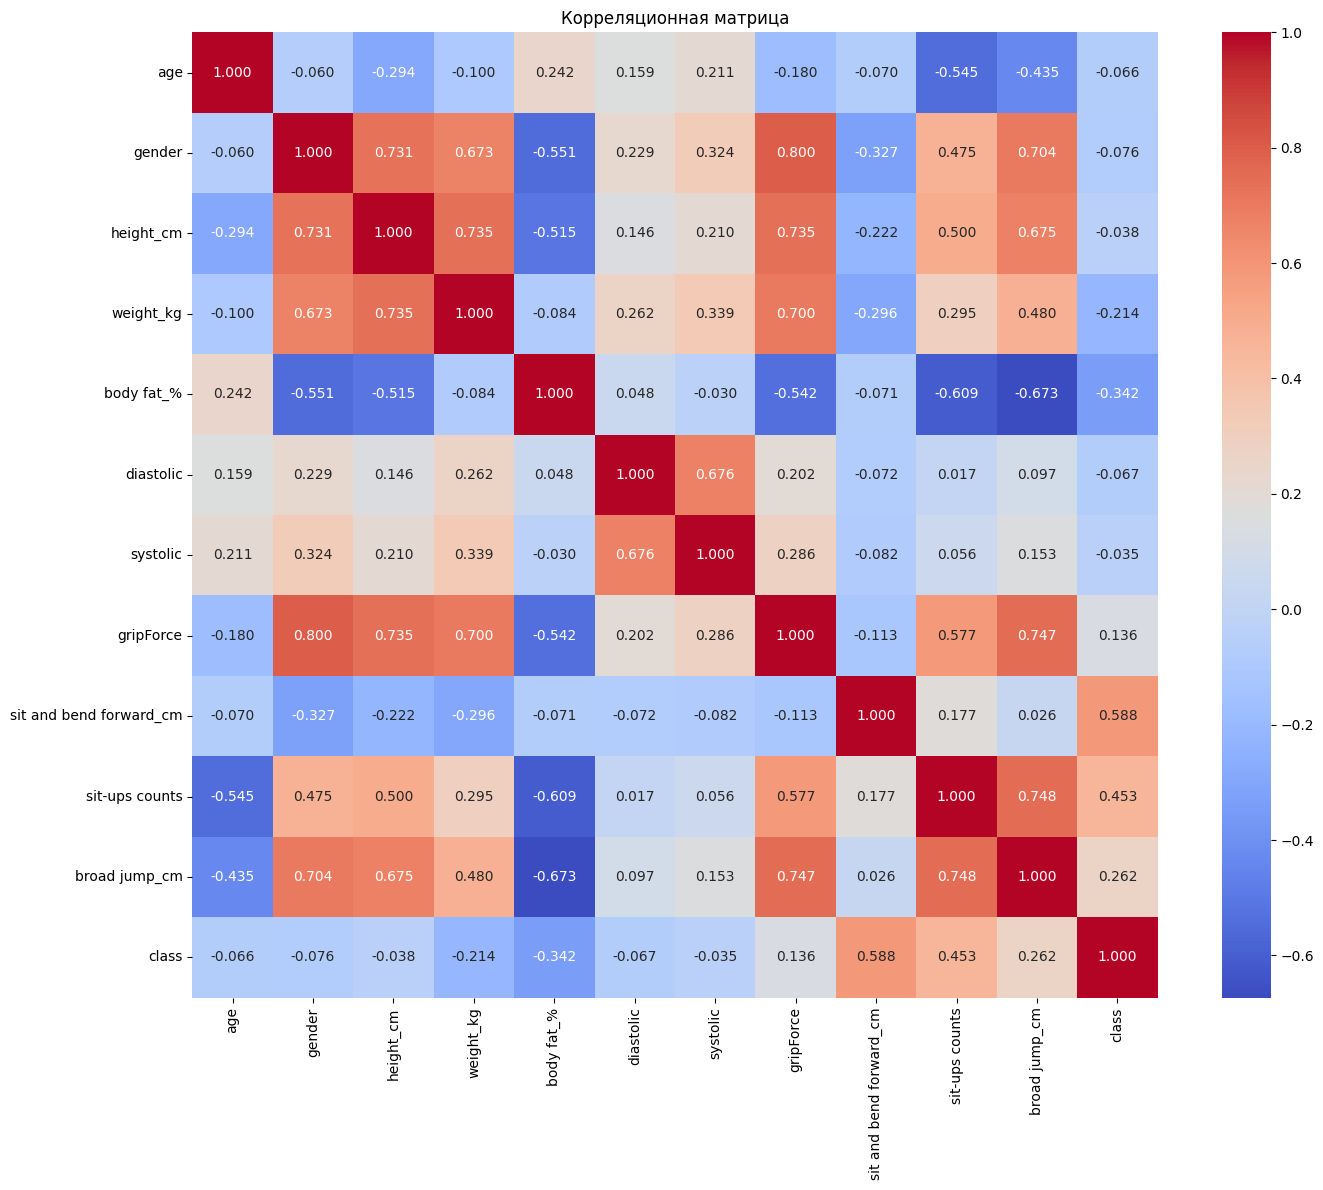

In [40]:
M_corr = df2.corr()

plt.figure(figsize=(15, 12))
sns.heatmap(M_corr, 
            annot=True, 
            fmt='.3f', 
            cmap='coolwarm', 
            square=True)
plt.title('Корреляционная матрица')
plt.tight_layout()
plt.show()

Очевидно здесь много признаков сильно коррелируют друг с другом (например, рост и вес)

#### Фильтрация признаков

In [41]:
knn_s = KNeighborsClassifier(n_neighbors=5)
sfs = SequentialFeatureSelector(knn_s, direction='forward', n_features_to_select='auto', cv=5)

sfs.fit(X_train, y_train)
X_train_filtered = sfs.transform(X_train)
X_test_filtered = sfs.transform(X_test)

print(f"Осталось признаков: {sfs.n_features_to_select_}")

Осталось признаков: 5


### Осуществить многоклассовую классификацию с отфильтрованными признаками

In [42]:
knn_f = KNeighborsClassifier(n_neighbors=k)
knn_f.fit(X_train_filtered, y_train)
y_pred_f = knn_f.predict(X_test_filtered)

### Посчитать метрики: $accuracy$, $precision$, $recall$, $\textit{f-measure}$, а также составить `classification_report`

In [43]:
accuracy_f = accuracy_score(y_test, y_pred_f)
precision_macro_f = precision_score(y_test, y_pred_f, average='macro')
precision_weighted_f = precision_score(y_test, y_pred_f, average='weighted')
recall_macro_f = recall_score(y_test, y_pred_f, average='macro')
recall_weighted_f = recall_score(y_test, y_pred_f, average='weighted')
f1_macro_f = f1_score(y_test, y_pred_f, average='macro')
f1_weighted_f = f1_score(y_test, y_pred_f, average='weighted')
class_report_f = classification_report(y_test, y_pred_f, target_names=['D', 'C', 'B', 'A'])

print(f"Accuracy:  {accuracy_f:.4f}")
print(f"Precision (macro):    {precision_macro_f:.4f}")
print(f"Precision (weighted): {precision_weighted_f:.4f}")
print(f"Recall (macro):        {recall_macro_f:.4f}")
print(f"Recall (weighted):    {recall_weighted_f:.4f}")
print(f"F1-Measure (macro):    {f1_macro_f:.4f}")
print(f"F1-Measure (weighted): {f1_weighted_f:.4f}")
print("\nCLASSIFICATION REPORT")
print(class_report_f)

Accuracy:  0.6603
Precision (macro):    0.6641
Precision (weighted): 0.6660
Recall (macro):        0.6587
Recall (weighted):    0.6603
F1-Measure (macro):    0.6606
F1-Measure (weighted): 0.6624

CLASSIFICATION REPORT
              precision    recall  f1-score   support

           D       0.86      0.78      0.82       682
           C       0.60      0.62      0.61       650
           B       0.50      0.51      0.51       662
           A       0.69      0.73      0.71       685

    accuracy                           0.66      2679
   macro avg       0.66      0.66      0.66      2679
weighted avg       0.67      0.66      0.66      2679



### Сравнить результаты "до" и "после" фильтрации, сделать выводы

In [44]:
comparison_data = {
    'Metric': [
        'Accuracy', 
        'Precision (macro)', 
        'Precision (weighted)', 
        'Recall (macro)', 
        'Recall (weighted)', 
        'F1-Macro', 
        'F1-Weighted'
    ],
    'Base': [
        accuracy, 
        precision_macro, 
        precision_weighted, 
        recall_macro, 
        recall_weighted, 
        f1_macro, 
        f1_weighted
    ],
    'Filtered': [
        accuracy_f, 
        precision_macro_f, 
        precision_weighted_f, 
        recall_macro_f, 
        recall_weighted_f, 
        f1_macro_f, 
        f1_weighted_f
    ],
    'Delta': [
        accuracy_f - accuracy, 
        precision_macro_f - precision_macro, 
        precision_weighted_f - precision_weighted, 
        recall_macro_f - recall_macro, 
        recall_weighted_f - recall_weighted, 
        f1_macro_f - f1_macro, 
        f1_weighted_f - f1_weighted
    ]
}

comparison_df = pd.DataFrame(comparison_data)
comparison_df

,Metric,Base,Filtered,Delta
0,Accuracy,0.610676,0.660321,0.049645
1,Precision (macro),0.617466,0.664054,0.046588
2,Precision (weighted),0.619978,0.666002,0.046025
3,Recall (macro),0.608853,0.658663,0.049810
4,Recall (weighted),0.610676,0.660321,0.049645
5,F1-Macro,0.612226,0.660581,0.048356
6,F1-Weighted,0.614383,0.662371,0.047988


Применение фильтрации признаков привело к стабильному улучшению всех метрик качества модели: точность (Accuracy) выросла с 0.611 до 0.660, а показатели F1-macro и F1-weighted увеличились примерно на 0.048, что свидетельствует об эффективности отбора признаков для снижения шума и избыточности данных.

Классификатор KNN демонстрирует умеренное качество работы: базовые метрики на уровне 0.61–0.66 указывают на то, что модель способна выявлять закономерности, но имеет существенный запас для улучшения. Положительным аспектом является согласованность метрик Precision, Recall и F1, что говорит об отсутствии сильного дисбаланса в предсказаниях. Однако абсолютные значения остаются недостаточно высокими для задач, требующих высокой надёжности.

### Перебрать значения гиперпараметра $k$ в каком-нибудь диапазоне с использованием кросс-валидации на данных
> данных &ndash; исходных данных до разбиения с применением нормализации с отфильтрованными признаками. Построить график *train/test accuracy* в зависимости от значения $k$.

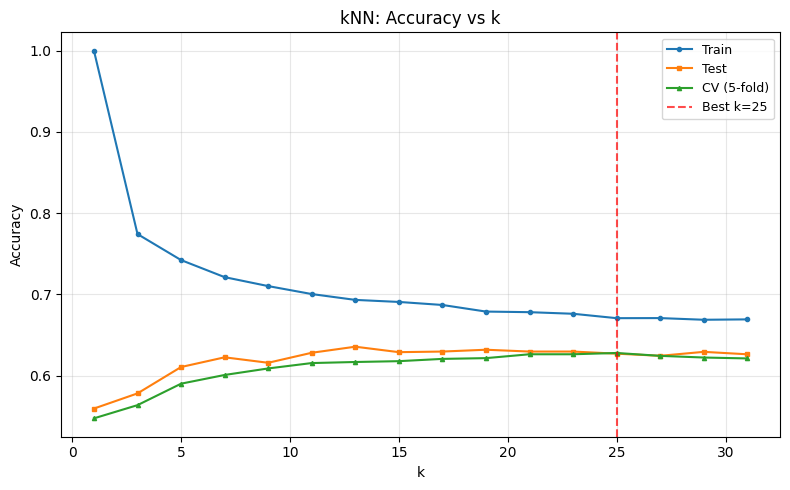

In [45]:
k_range = range(1, 32, 2)
train_acc, test_acc, cv_acc = [], [], []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    train_acc.append(knn.score(X_train, y_train))
    test_acc.append(knn.score(X_test, y_test))
    cv_acc.append(cross_val_score(knn, X_train, y_train, cv=5).mean())

plt.figure(figsize=(8, 5))
plt.plot(k_range, train_acc, label='Train', marker='o', markersize=3)
plt.plot(k_range, test_acc, label='Test', marker='s', markersize=3)
plt.plot(k_range, cv_acc, label='CV (5-fold)', marker='^', markersize=3)

best_k = k_range[np.argmax(cv_acc)]
plt.axvline(best_k, color='red', linestyle='--', alpha=0.7, label=f'Best k={best_k}')

plt.xlabel('k')
plt.ylabel('Accuracy')
plt.title('kNN: Accuracy vs k')
plt.legend(fontsize=9)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()